In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('student_performance_updated_1000.csv')
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB


In [3]:
df.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,950.000000,967.000000,957.000000,960.000000,976.000000,959.000000
mean,5416.019792,85.510417,17.630526,77.598759,1.520376,80.030208,2.406967,77.248175
std,2653.748319,7.332125,6.272132,10.006640,1.046439,9.493652,1.620267,19.298148
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3113.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,63.000000
50%,5396.500000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,7754.750000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


In [4]:
df.drop(columns = ['StudentID', 'Name'], inplace = True)
df.head()

,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


<Axes: xlabel='Gender', ylabel='AttendanceRate'>

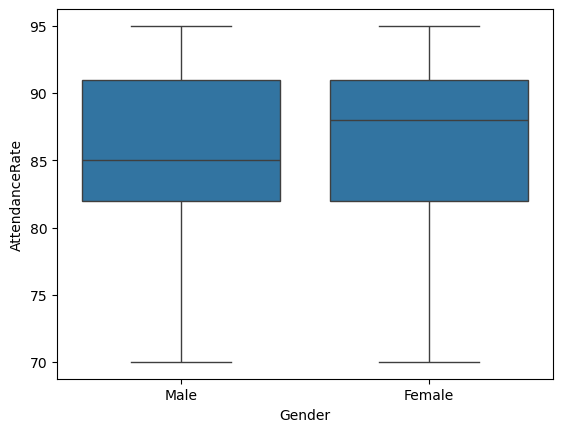

In [5]:
sns.boxplot(df, x = 'Gender', y = 'AttendanceRate')

In [6]:
for i in df.columns:
    print(i, '=', sum(df[i].isnull()) / (len(df)) * 100)

Gender = 4.8
AttendanceRate = 4.0
StudyHoursPerWeek = 5.0
PreviousGrade = 3.3000000000000003
ExtracurricularActivities = 4.3
ParentalSupport = 2.1999999999999997
FinalGrade = 4.0
Study Hours = 2.4
Attendance (%) = 4.1000000000000005
Online Classes Taken = 2.5


In [7]:
num_col = df.select_dtypes(include = ['float64'])
cat_col = df.select_dtypes(include = ['object'])

display(num_col, cat_col)

,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
0,85.0,15.0,78.0,1.0,80.0,4.8,59.0
1,90.0,20.0,85.0,2.0,87.0,2.2,70.0
2,78.0,10.0,65.0,0.0,68.0,4.6,92.0
3,92.0,25.0,90.0,3.0,92.0,2.9,96.0
4,NaN,18.0,82.0,2.0,85.0,4.1,97.0
...,...,...,...,...,...,...,...
995,85.0,20.0,NaN,1.0,72.0,0.8,80.0
996,91.0,NaN,86.0,0.0,90.0,3.9,80.0
997,85.0,8.0,82.0,2.0,68.0,0.4,54.0
998,88.0,17.0,60.0,2.0,85.0,0.9,53.0


,Gender,ParentalSupport,Online Classes Taken
0,Male,High,False
1,Female,Medium,True
2,Male,Low,False
3,Male,High,False
4,Female,Medium,True
...,...,...,...
995,Male,High,True
996,Female,High,True
997,Male,Low,False
998,Male,High,True


In [8]:
for i in num_col.columns:
    df[i].fillna(df[i].median(), inplace = True)

for i in cat_col.columns:
    df[i].fillna(df[i].mode()[0], inplace = True)

df.head()

/tmp/ipykernel_45784/1040027445.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].median(), inplace = True)
/tmp/ipykernel_45784/1040027445.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,Female,88.0,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Gender                     1000 non-null   object 
 1   AttendanceRate             1000 non-null   float64
 2   StudyHoursPerWeek          1000 non-null   float64
 3   PreviousGrade              1000 non-null   float64
 4   ExtracurricularActivities  1000 non-null   float64
 5   ParentalSupport            1000 non-null   object 
 6   FinalGrade                 1000 non-null   float64
 7   Study Hours                1000 non-null   float64
 8   Attendance (%)             1000 non-null   float64
 9   Online Classes Taken       1000 non-null   bool   
dtypes: bool(1), float64(7), object(2)
memory usage: 71.4+ KB


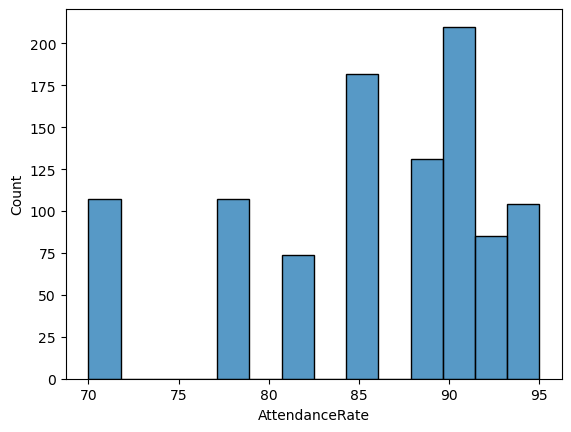

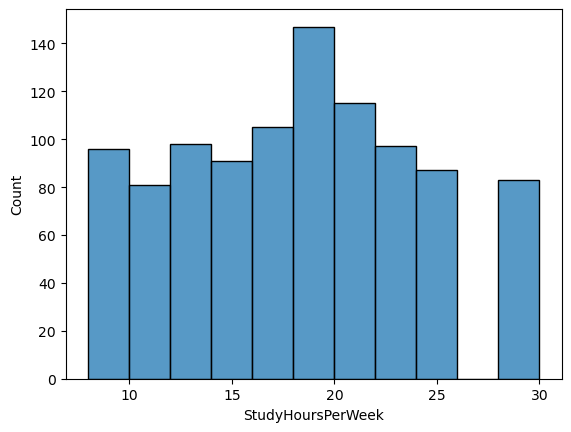

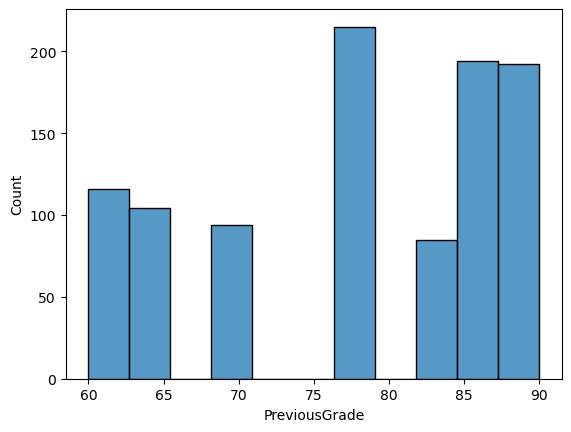

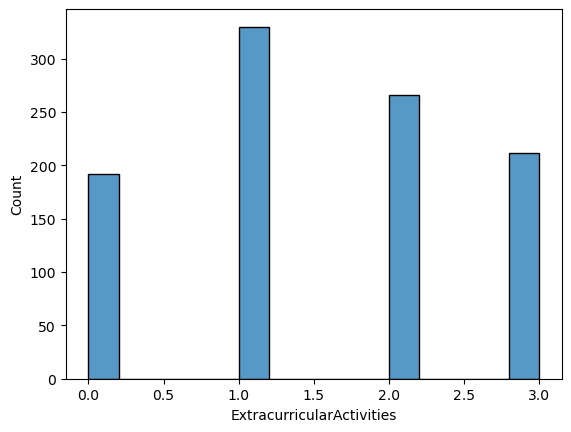

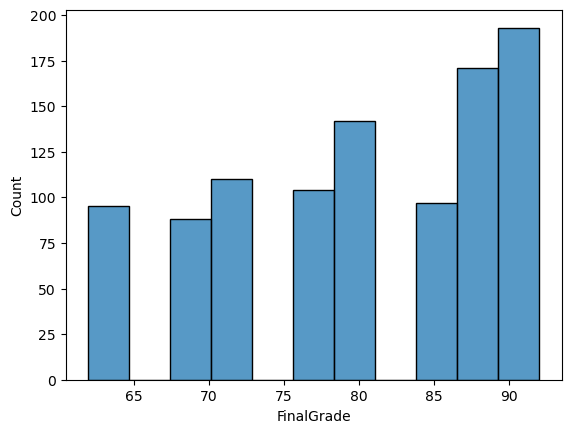

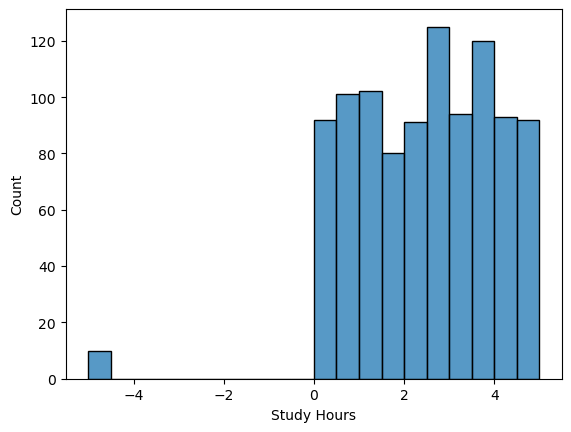

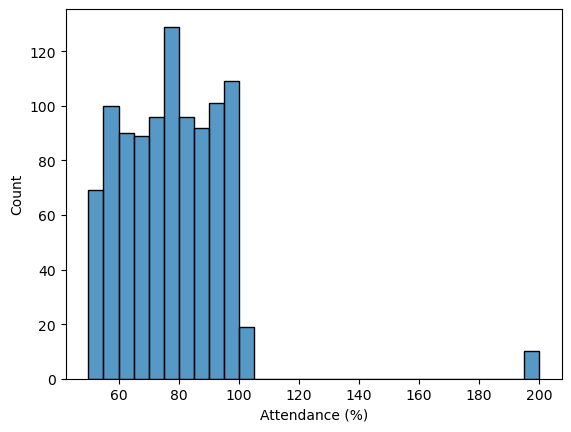

In [10]:
for i in num_col:
    sns.histplot(df[i])
    plt.show()

array([[<Axes: title={'center': 'AttendanceRate'}>,
        <Axes: title={'center': 'StudyHoursPerWeek'}>,
        <Axes: title={'center': 'PreviousGrade'}>],
       [<Axes: title={'center': 'ExtracurricularActivities'}>,
        <Axes: title={'center': 'FinalGrade'}>,
        <Axes: title={'center': 'Study Hours'}>],
       [<Axes: title={'center': 'Attendance (%)'}>, <Axes: >, <Axes: >]],
      dtype=object)

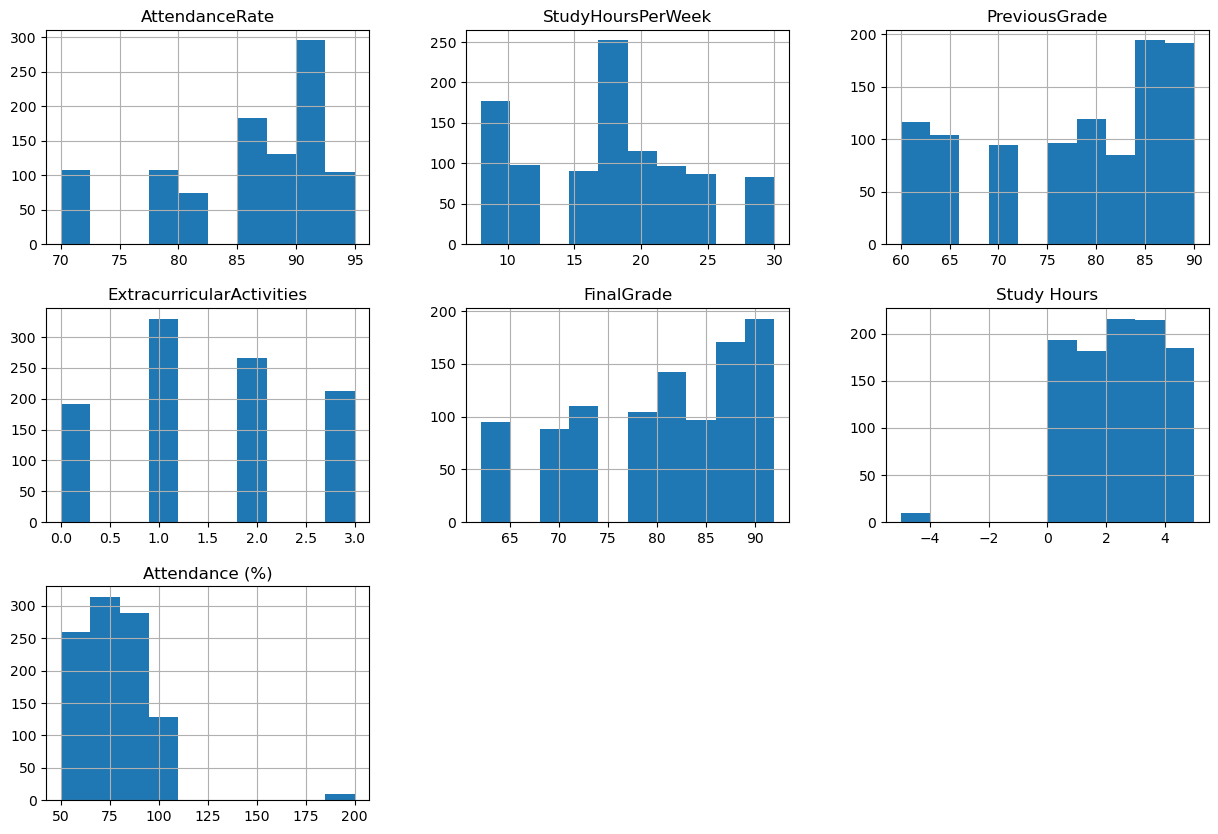

In [11]:
df.hist(figsize=(15, 10))

<Axes: xlabel='Study Hours', ylabel='Count'>

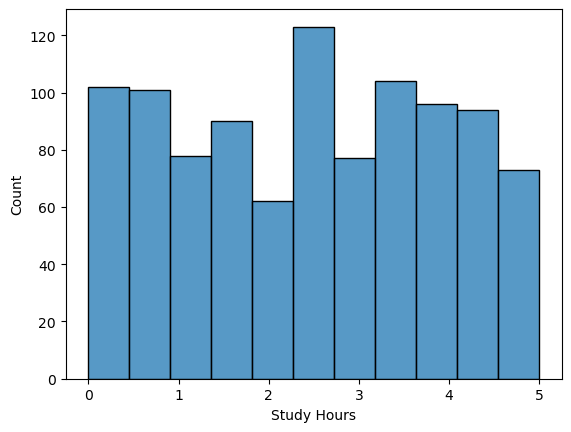

In [12]:
df['Study Hours'] = df['Study Hours'].clip(0, 5)

sns.histplot(df['Study Hours'])

<Axes: xlabel='Attendance (%)', ylabel='Count'>

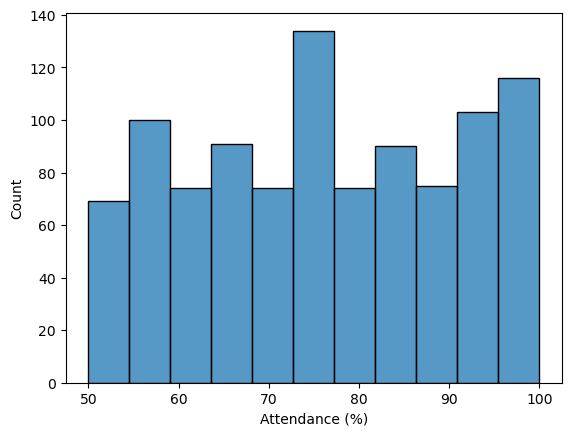

In [13]:
df['Attendance (%)'] = df['Attendance (%)'].clip(1, 100)

sns.histplot(df['Attendance (%)'])

In [14]:
df.head(10)

,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,Female,88.0,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
5,Female,95.0,30.0,88.0,1.0,High,80.0,2.8,97.0,False
6,Male,70.0,8.0,60.0,0.0,Low,62.0,4.5,96.0,False
7,Female,88.0,17.0,77.0,1.0,Medium,78.0,1.0,70.0,True
8,Male,82.0,12.0,70.0,2.0,Low,72.0,3.6,50.0,False
9,Female,91.0,22.0,86.0,3.0,High,88.0,2.9,59.0,True


In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df.head()

,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,0,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,1,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,1,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,0,88.0,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Online Classes Taken'] = le.fit_transform(df['Online Classes Taken'])
df.head()

,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,0
1,0,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,1
2,1,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,0
3,1,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,0
4,0,88.0,18.0,82.0,2.0,Medium,85.0,4.1,97.0,1


In [17]:
df = pd.get_dummies(df, columns = ['ParentalSupport'], dtype = 'int')

In [18]:
num_col.columns

Index(['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
       'ExtracurricularActivities', 'FinalGrade', 'Study Hours',
       'Attendance (%)'],
      dtype='object')

In [19]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
df[num_col.columns] = ss.fit_transform(df[num_col.columns])
df.head()

,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%),Online Classes Taken,ParentalSupport_High,ParentalSupport_Low,ParentalSupport_Medium
0,1,-0.084760,-0.433507,0.039450,-0.484158,-0.003119,1.628379,-1.186050,0,1,0,0
1,0,0.609994,0.384739,0.751171,0.488047,0.749812,-0.180313,-0.427397,1,0,0,1
2,1,-1.057415,-1.251753,-1.282318,-1.456364,-1.293859,1.489249,1.089908,0,0,1,0
3,1,0.887895,1.202986,1.259543,1.460252,1.287620,0.306643,1.365782,0,1,0,0
4,0,0.332092,0.057441,0.446147,0.488047,0.534689,1.141424,1.434750,1,0,0,1


In [20]:
df.head()

,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%),Online Classes Taken,ParentalSupport_High,ParentalSupport_Low,ParentalSupport_Medium
0,1,-0.084760,-0.433507,0.039450,-0.484158,-0.003119,1.628379,-1.186050,0,1,0,0
1,0,0.609994,0.384739,0.751171,0.488047,0.749812,-0.180313,-0.427397,1,0,0,1
2,1,-1.057415,-1.251753,-1.282318,-1.456364,-1.293859,1.489249,1.089908,0,0,1,0
3,1,0.887895,1.202986,1.259543,1.460252,1.287620,0.306643,1.365782,0,1,0,0
4,0,0.332092,0.057441,0.446147,0.488047,0.534689,1.141424,1.434750,1,0,0,1


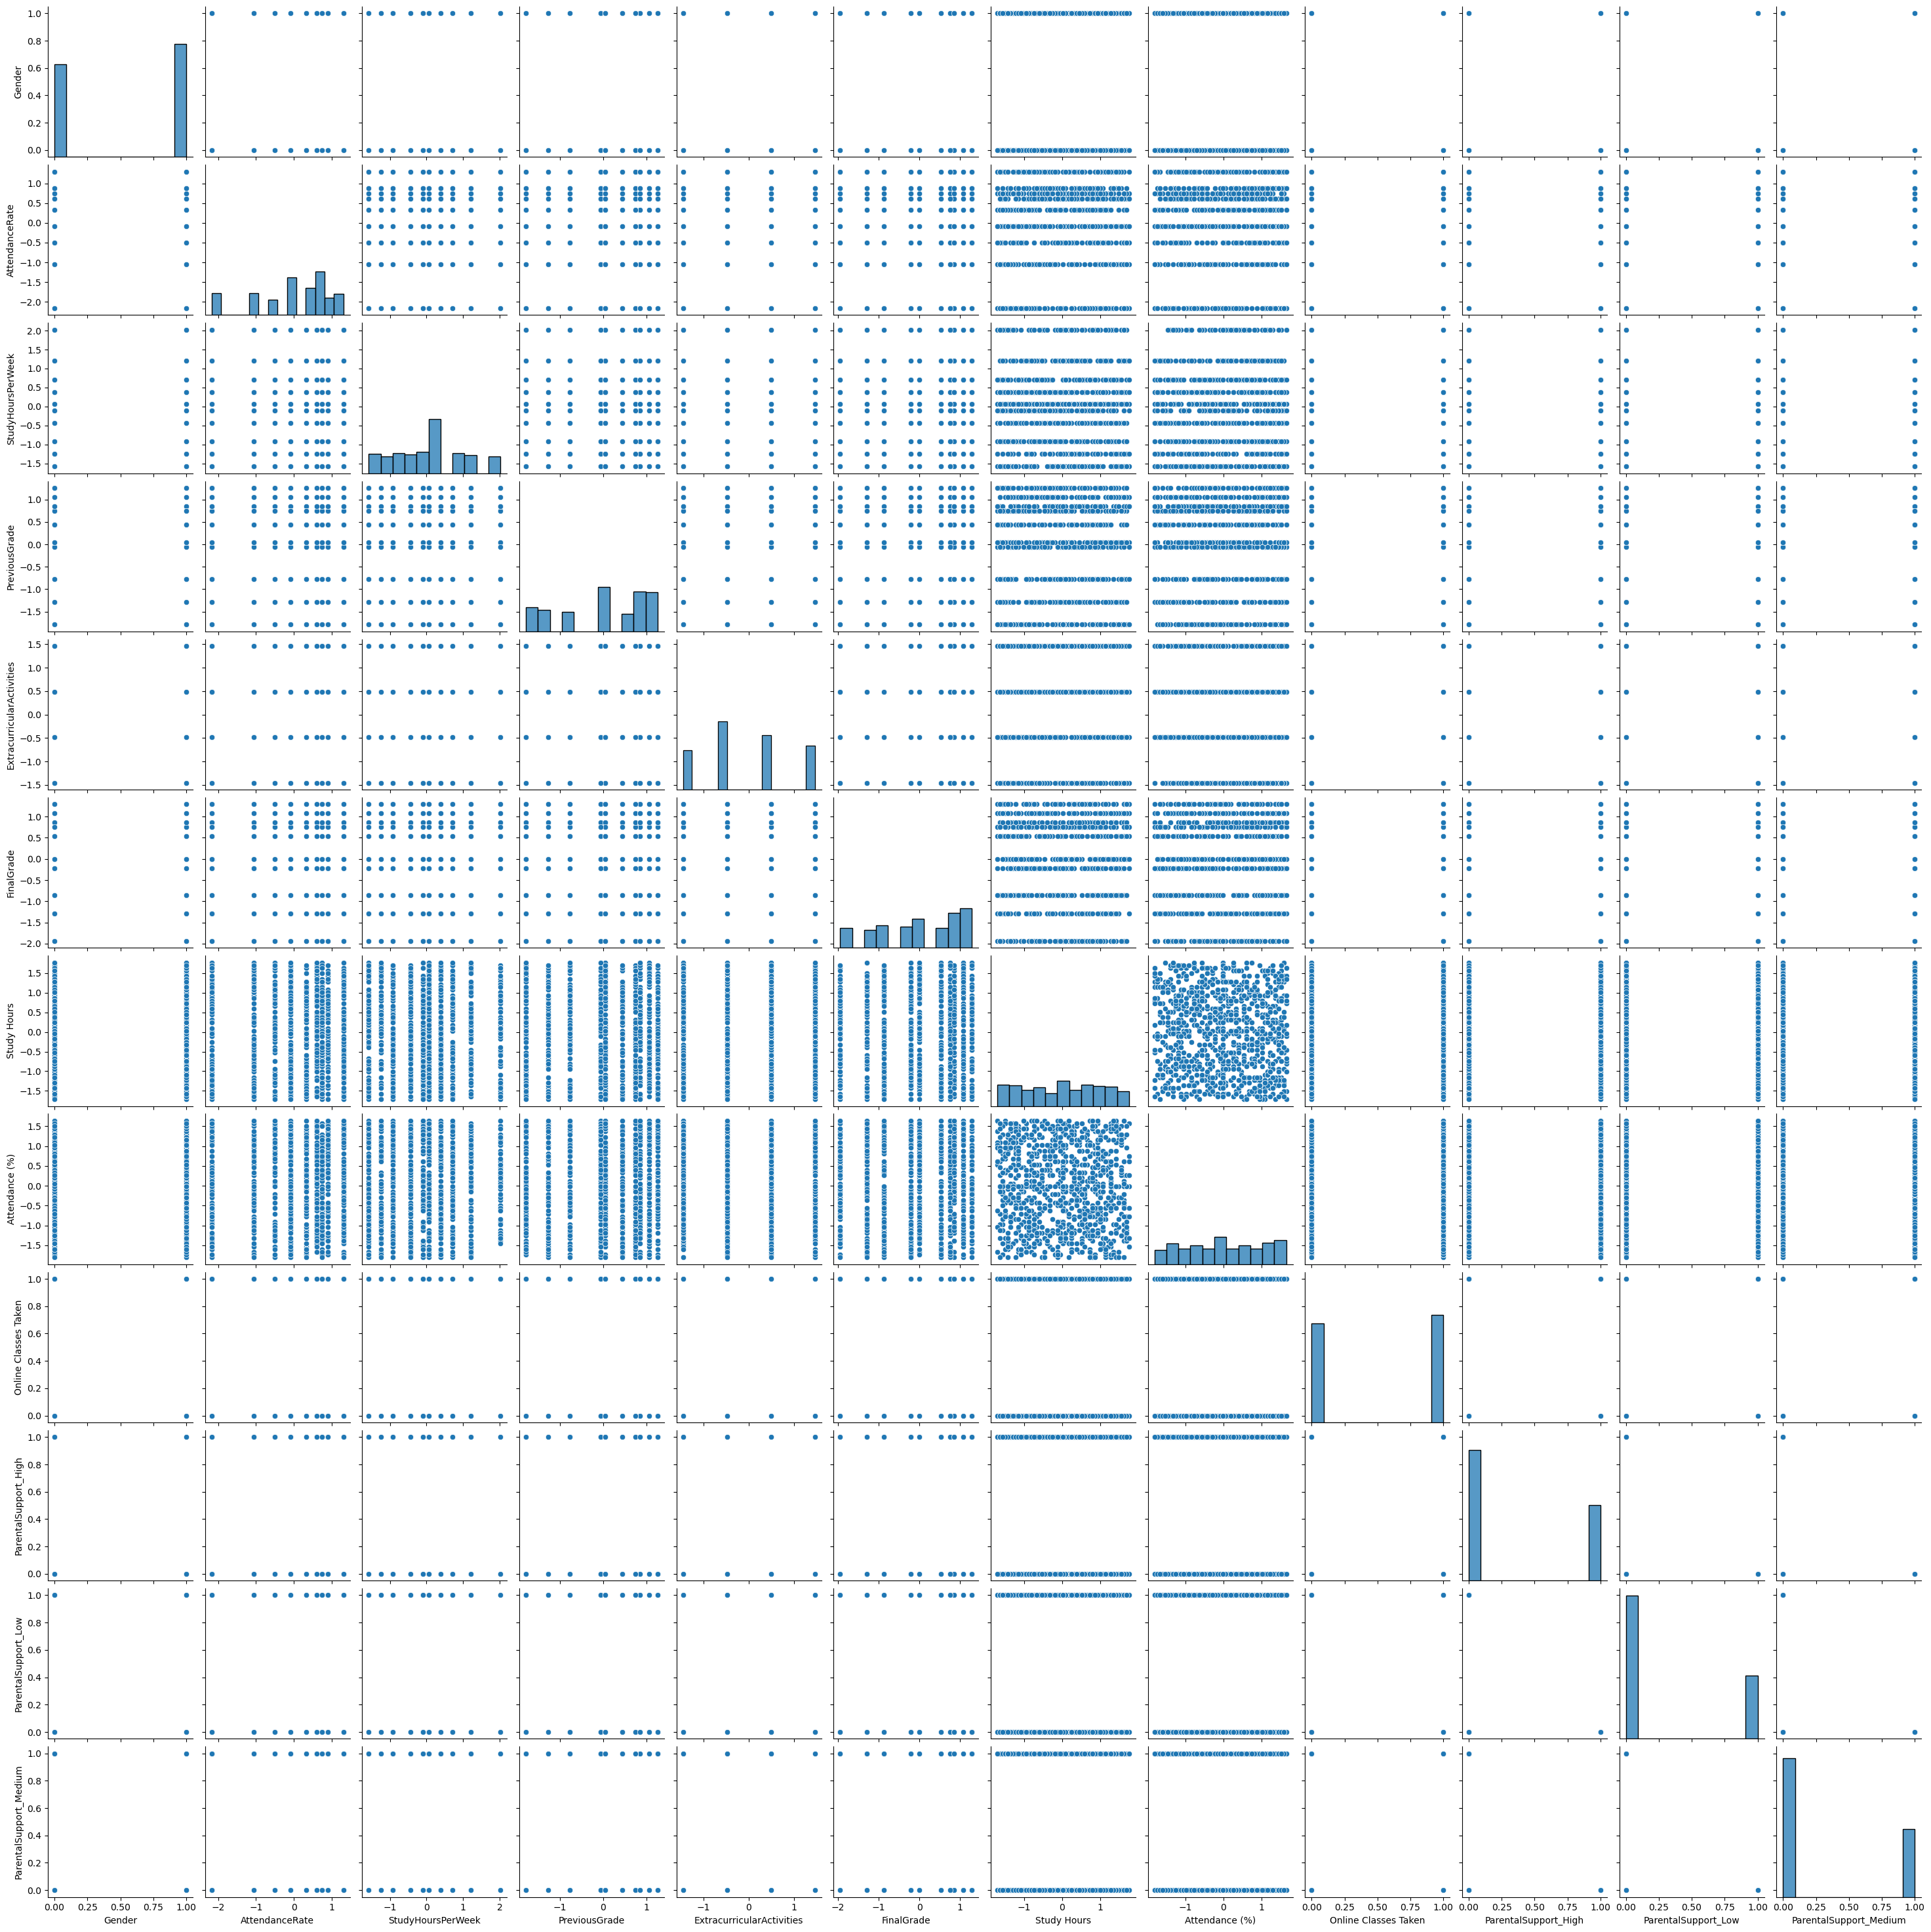

In [21]:
sns.pairplot(df)

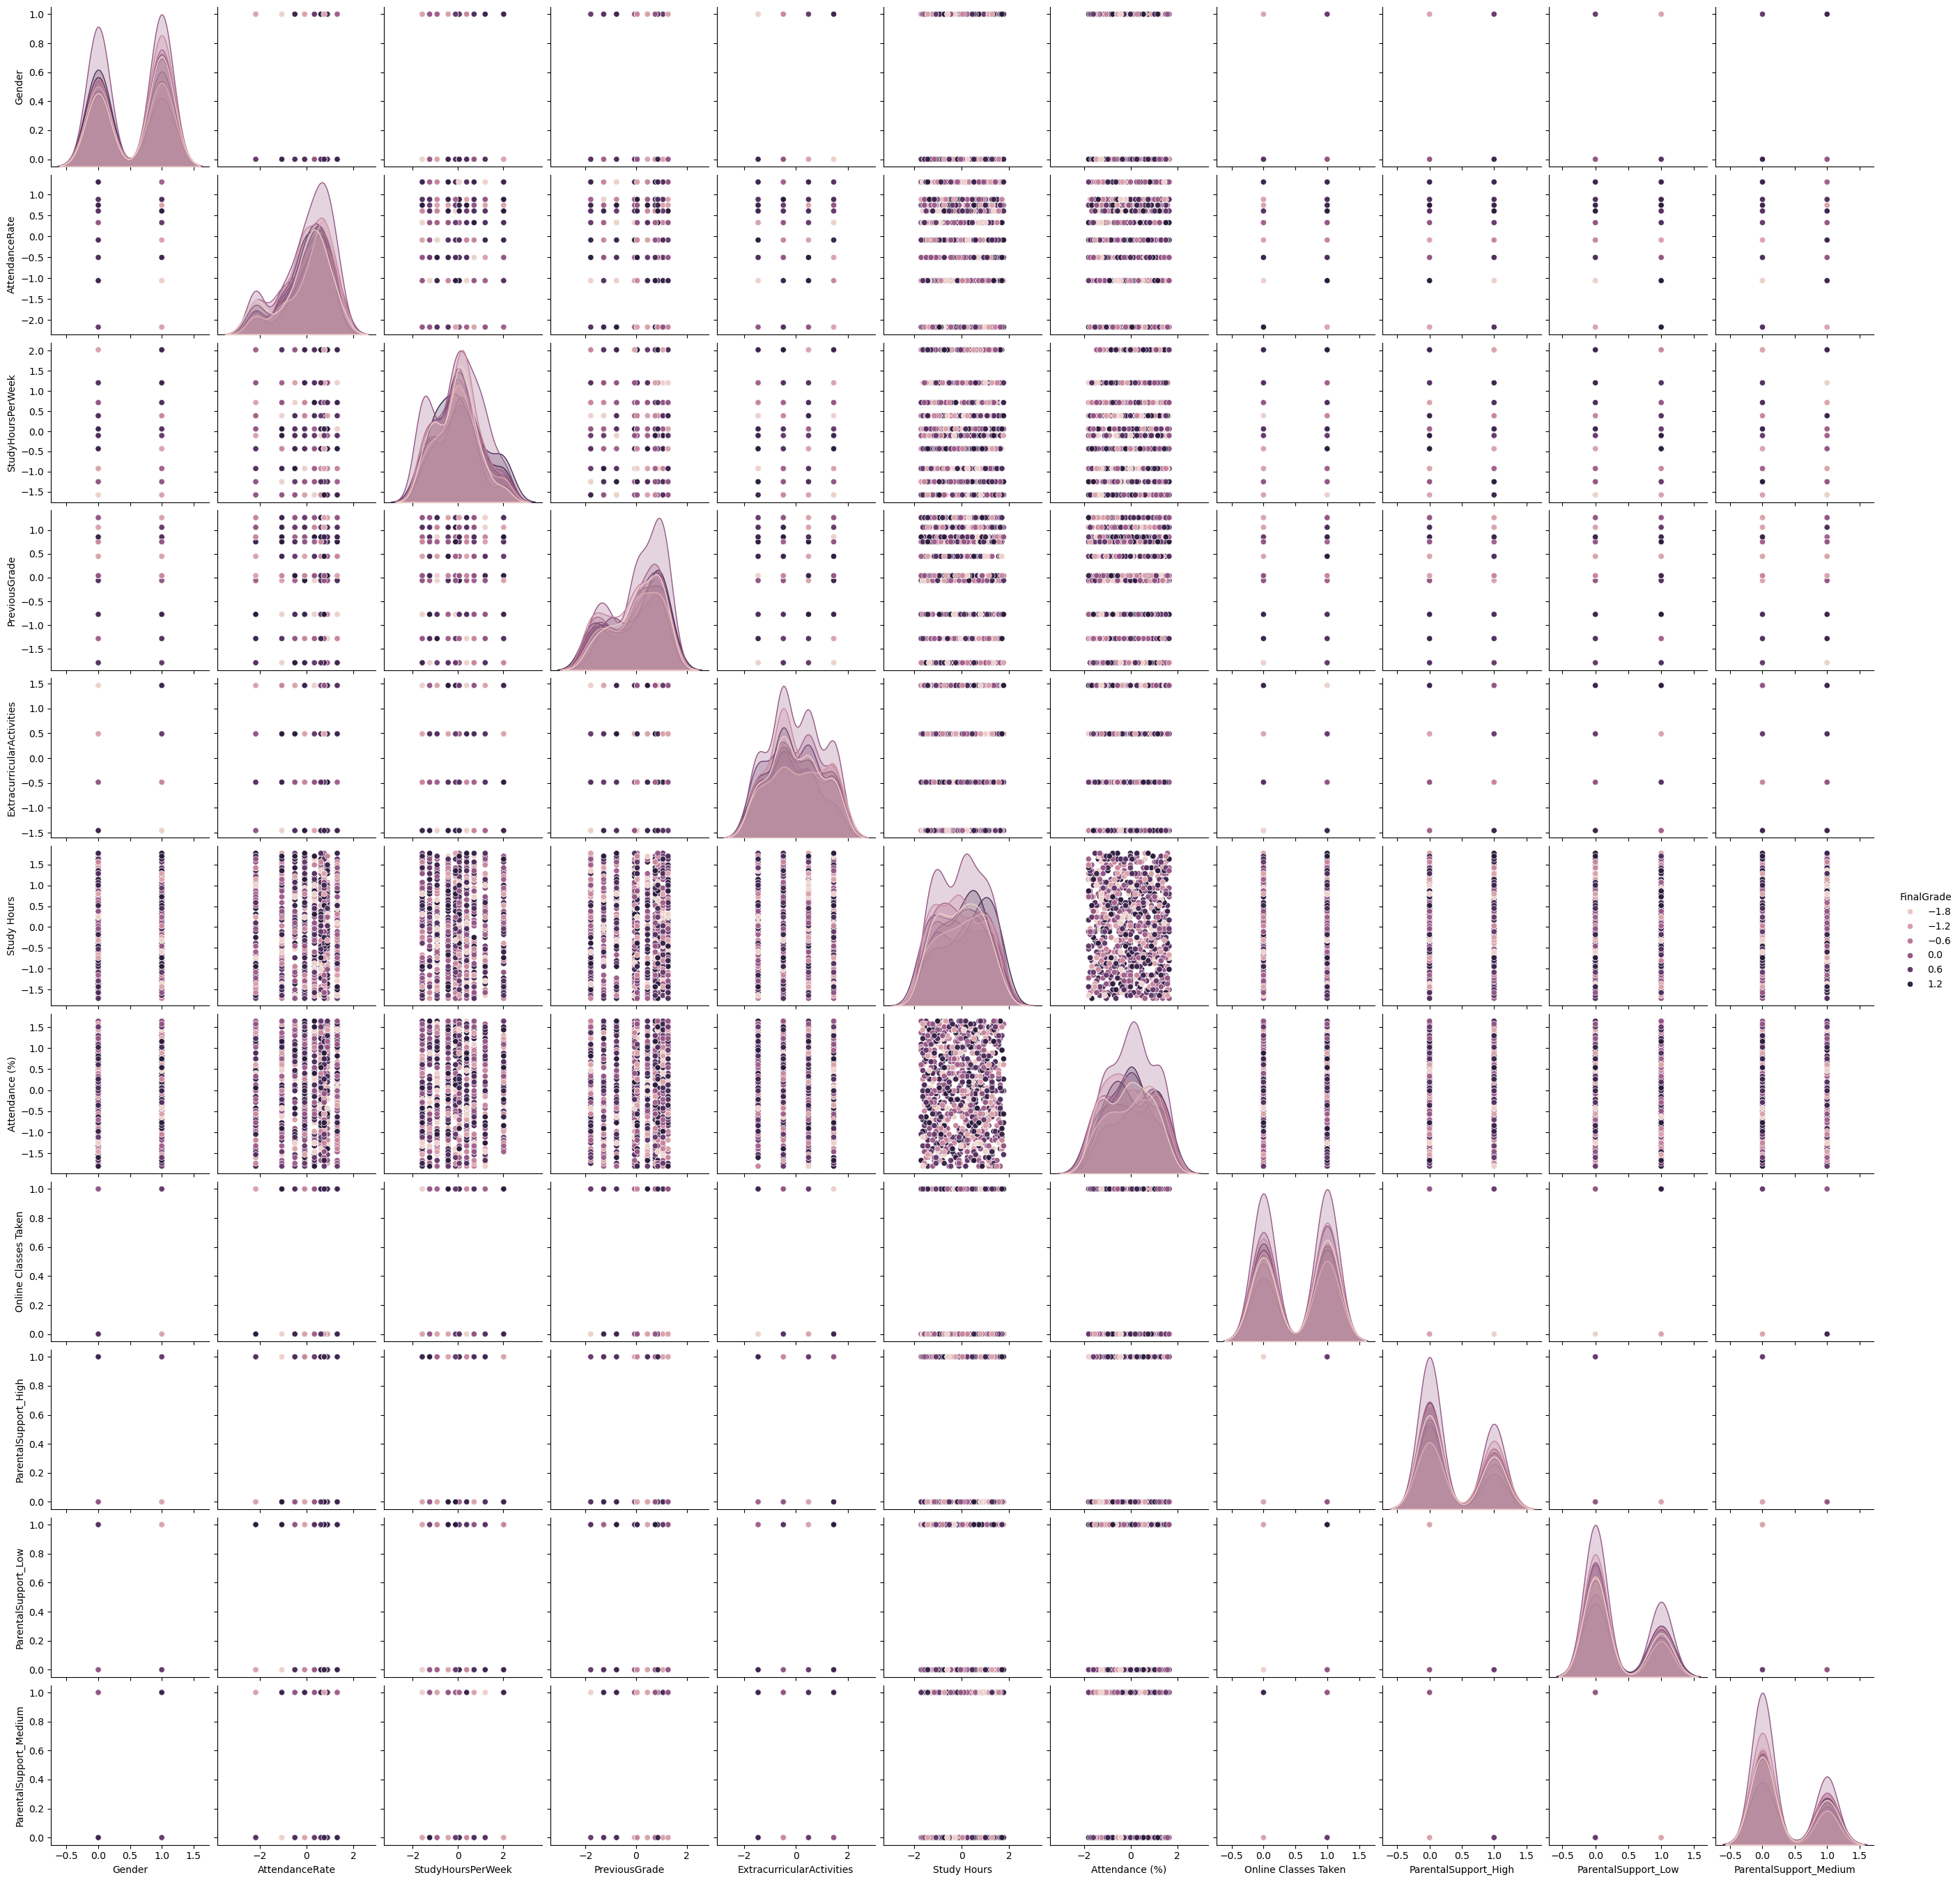

In [22]:
sns.pairplot(df, hue = 'FinalGrade')

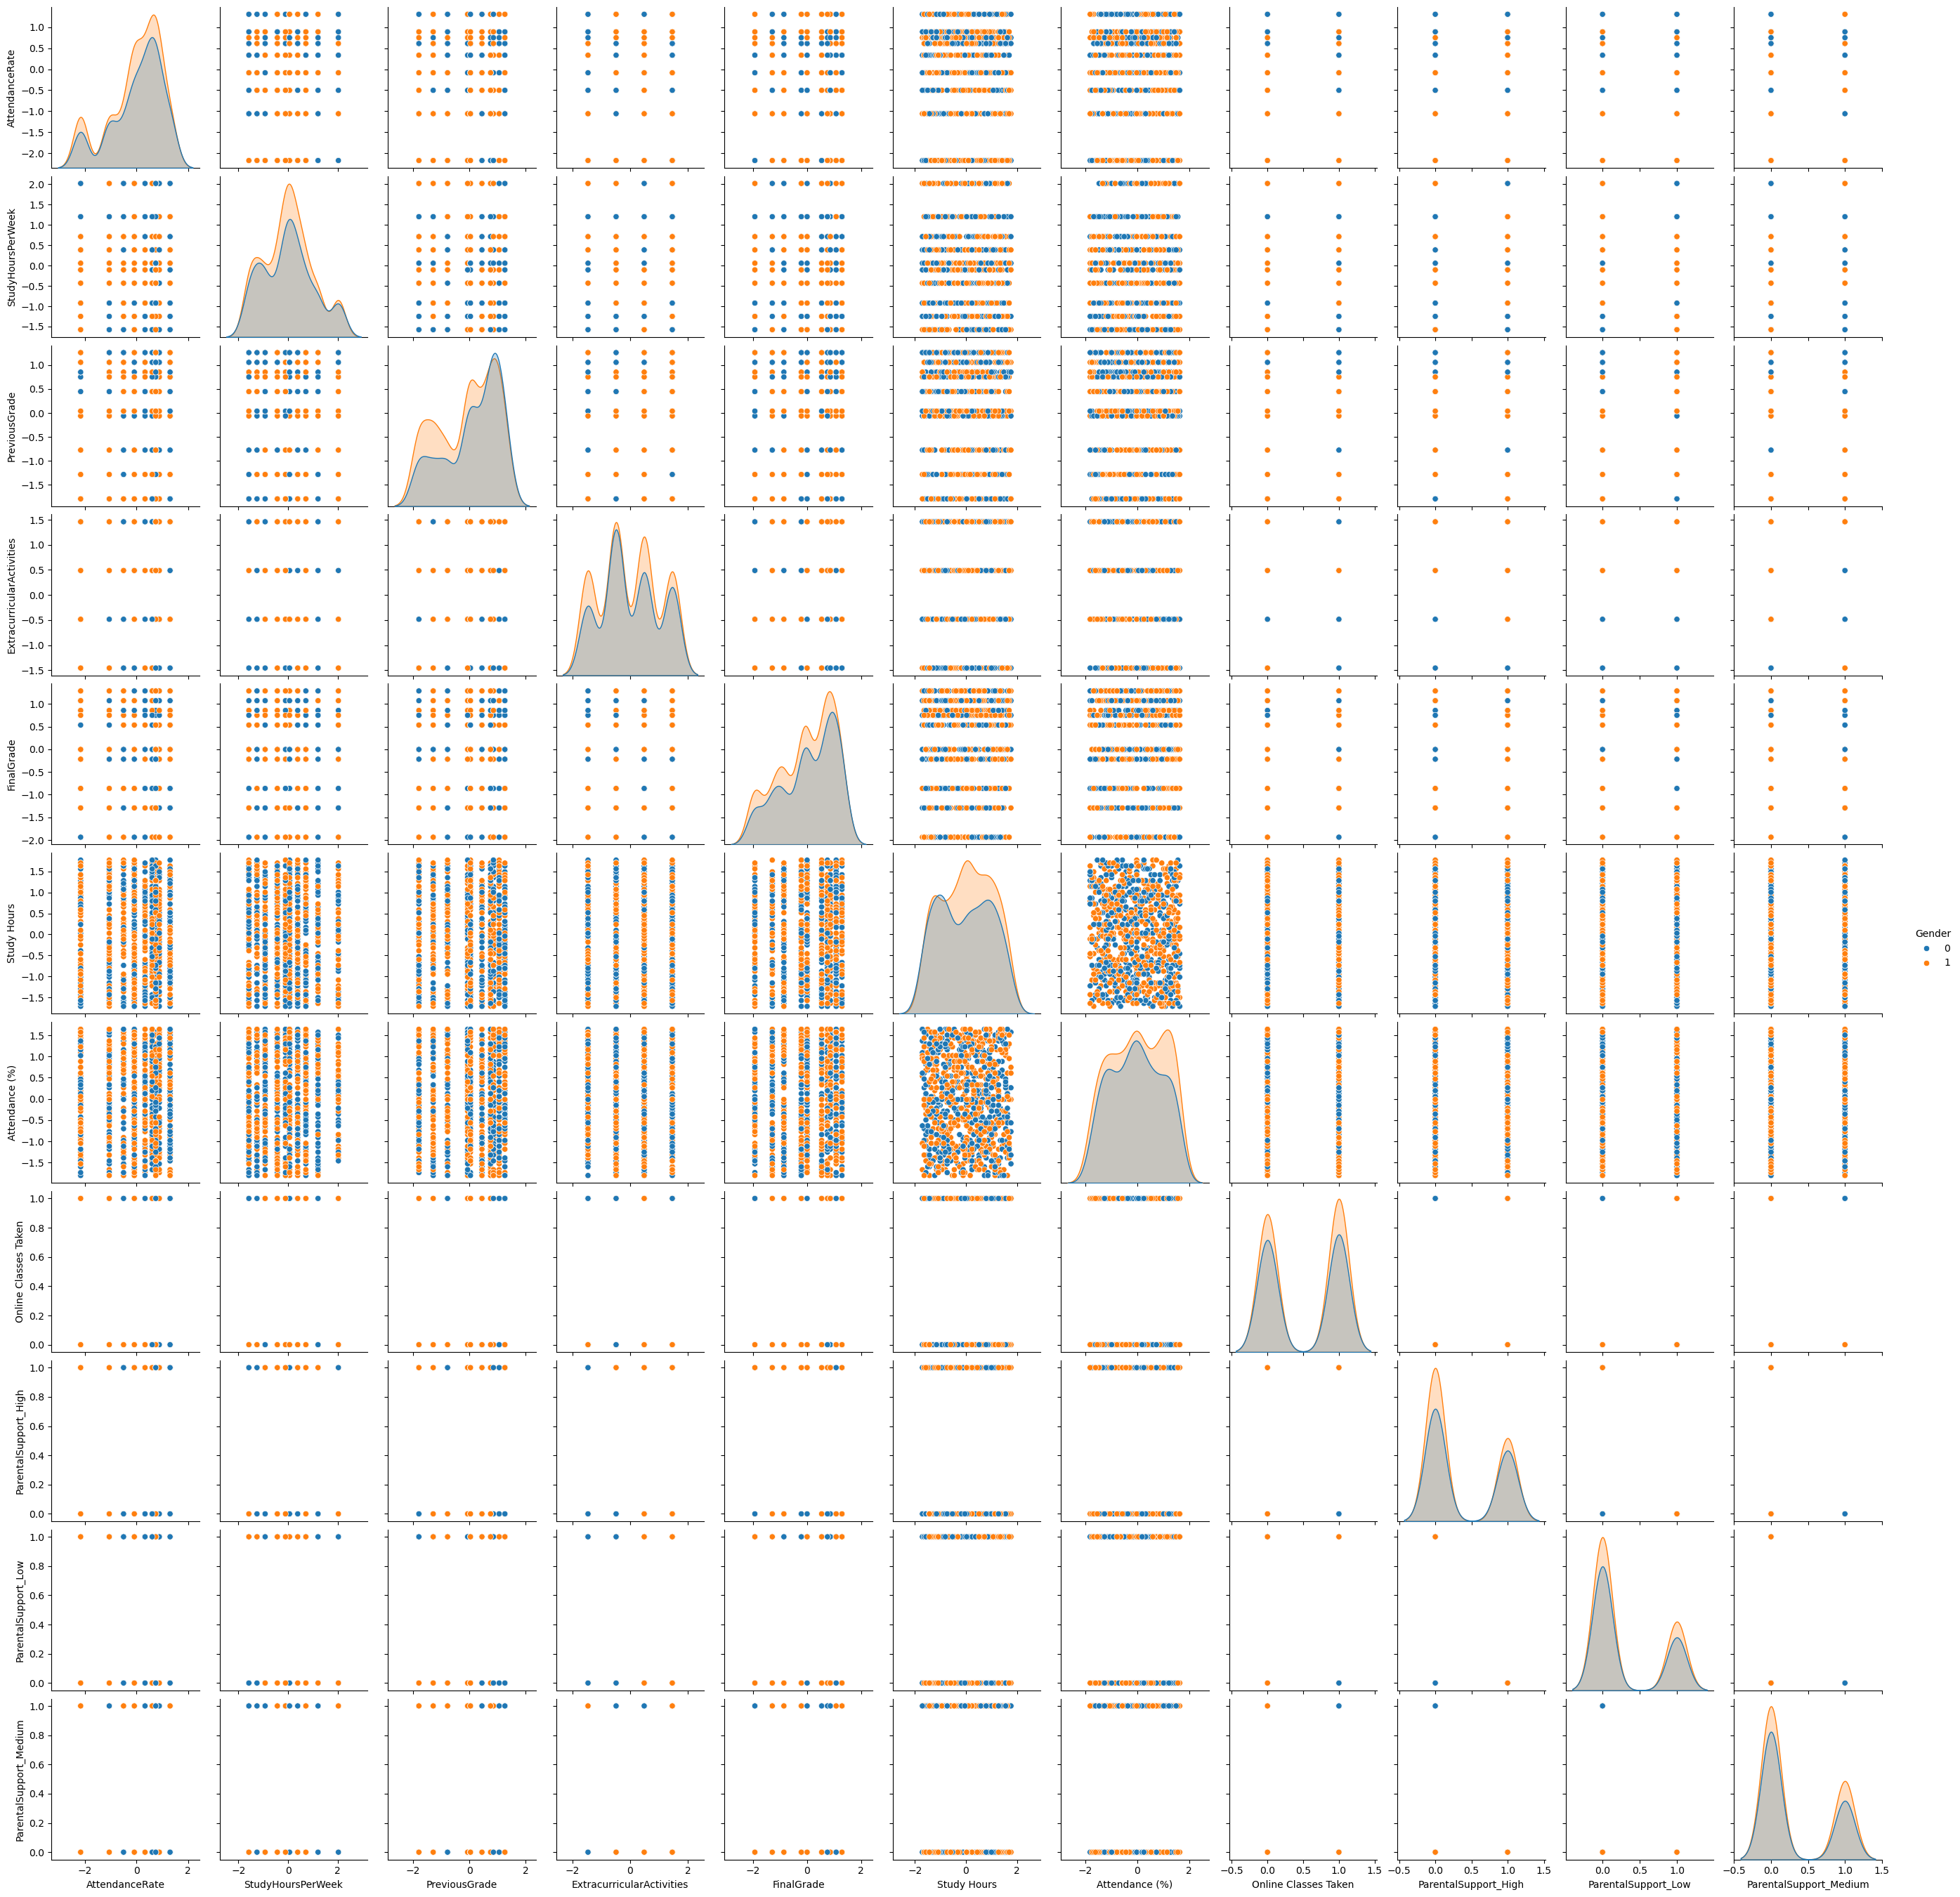

In [23]:
sns.pairplot(df, hue = 'Gender')

In [24]:
corr = df.corr(method = 'spearman', numeric_only = True)
corr

,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%),Online Classes Taken,ParentalSupport_High,ParentalSupport_Low,ParentalSupport_Medium
Gender,1.000000,-0.018429,-0.002177,-0.109300,-0.014506,-0.048449,0.038525,0.028893,0.014159,-0.035370,0.011153,0.025375
AttendanceRate,-0.018429,1.000000,0.016675,0.029405,-0.019387,-0.026532,-0.032822,0.020847,0.022617,0.010943,-0.017116,0.005550
StudyHoursPerWeek,-0.002177,0.016675,1.000000,-0.007547,0.028503,0.021590,-0.023971,0.054754,-0.042512,-0.027526,-0.002168,0.030384
PreviousGrade,-0.109300,0.029405,-0.007547,1.000000,0.052064,0.019400,-0.035983,0.056592,-0.039564,-0.015742,0.027545,-0.010851
ExtracurricularActivities,-0.014506,-0.019387,0.028503,0.052064,1.000000,-0.029713,-0.037807,-0.007194,-0.000432,-0.021935,0.033878,-0.010704
FinalGrade,-0.048449,-0.026532,0.021590,0.019400,-0.029713,1.000000,0.046627,0.040459,0.001074,-0.049895,0.020369,0.031248
Study Hours,0.038525,-0.032822,-0.023971,-0.035983,-0.037807,0.046627,1.000000,-0.033145,-0.028279,-0.047576,0.031808,0.017650
Attendance (%),0.028893,0.020847,0.054754,0.056592,-0.007194,0.040459,-0.033145,1.000000,0.033962,0.022941,0.033173,-0.056084
Online Classes Taken,0.014159,0.022617,-0.042512,-0.039564,-0.000432,0.001074,-0.028279,0.033962,1.000000,0.042193,0.023476,-0.066339
ParentalSupport_High,-0.035370,0.010943,-0.027526,-0.015742,-0.021935,-0.049895,-0.047576,0.022941,0.042193,1.000000,-0.504416,-0.531965


<Axes: >

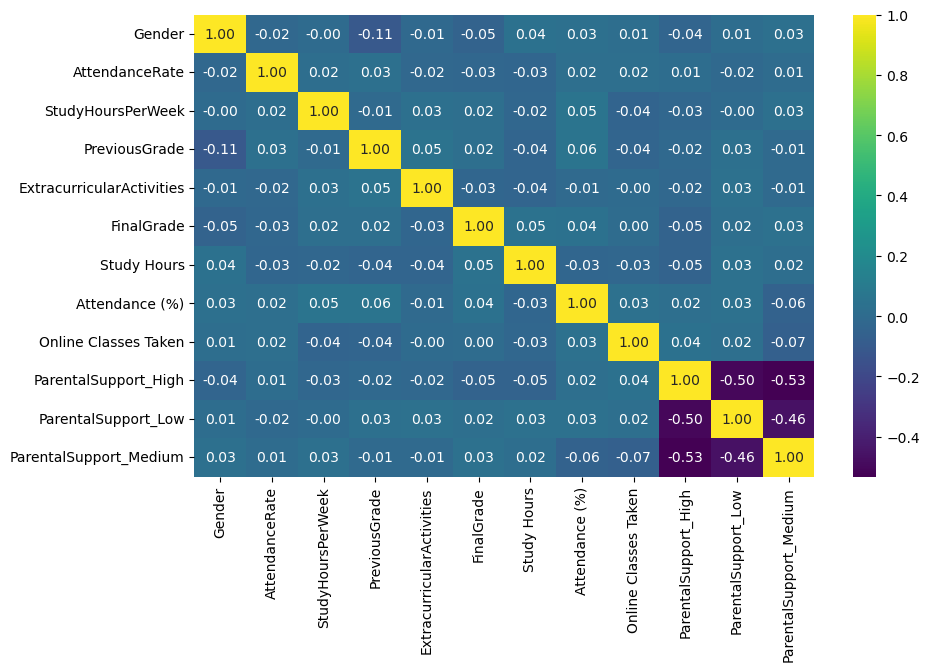

In [25]:
plt.figure(figsize = (10, 6))
sns.heatmap(corr, cmap = 'viridis', annot = True, fmt = '.2f')


In [26]:
covv = df.cov(numeric_only = True)
covv

,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%),Online Classes Taken,ParentalSupport_High,ParentalSupport_Low,ParentalSupport_Medium
Gender,0.247847,-0.010834,-0.002015,-0.053940,-0.008177,-0.020879,0.020263,0.013659,0.003524,-0.008491,0.002558,0.005934
AttendanceRate,-0.010834,1.001001,0.013865,0.034629,-0.017955,-0.011126,-0.028719,0.028259,0.015689,0.003913,-0.010717,0.006804
StudyHoursPerWeek,-0.002015,0.013865,1.001001,-0.010846,0.028475,0.034609,-0.019648,0.058977,-0.022030,-0.010842,-0.001793,0.012635
PreviousGrade,-0.053940,0.034629,-0.010846,1.001001,0.061567,0.003834,-0.039509,0.055428,-0.012543,-0.007593,0.007464,0.000129
ExtracurricularActivities,-0.008177,-0.017955,0.028475,0.061567,1.001001,-0.030193,-0.039118,-0.009068,-0.000934,-0.010477,0.015678,-0.005201
FinalGrade,-0.020879,-0.011126,0.034609,0.003834,-0.030193,1.001001,0.040235,0.038237,0.000637,-0.023326,0.009276,0.014050
Study Hours,0.020263,-0.028719,-0.019648,-0.039509,-0.039118,0.040235,1.001001,-0.033271,-0.013707,-0.023067,0.014306,0.008762
Attendance (%),0.013659,0.028259,0.058977,0.055428,-0.009068,0.038237,-0.033271,1.001001,0.017022,0.012061,0.014561,-0.026622
Online Classes Taken,0.003524,0.015689,-0.022030,-0.012543,-0.000934,0.000637,-0.013707,0.017022,0.249850,0.010170,0.005405,-0.015576
ParentalSupport_High,-0.008491,0.003913,-0.010842,-0.007593,-0.010477,-0.023326,-0.023067,0.012061,0.010170,0.232544,-0.112047,-0.120496


<Axes: >

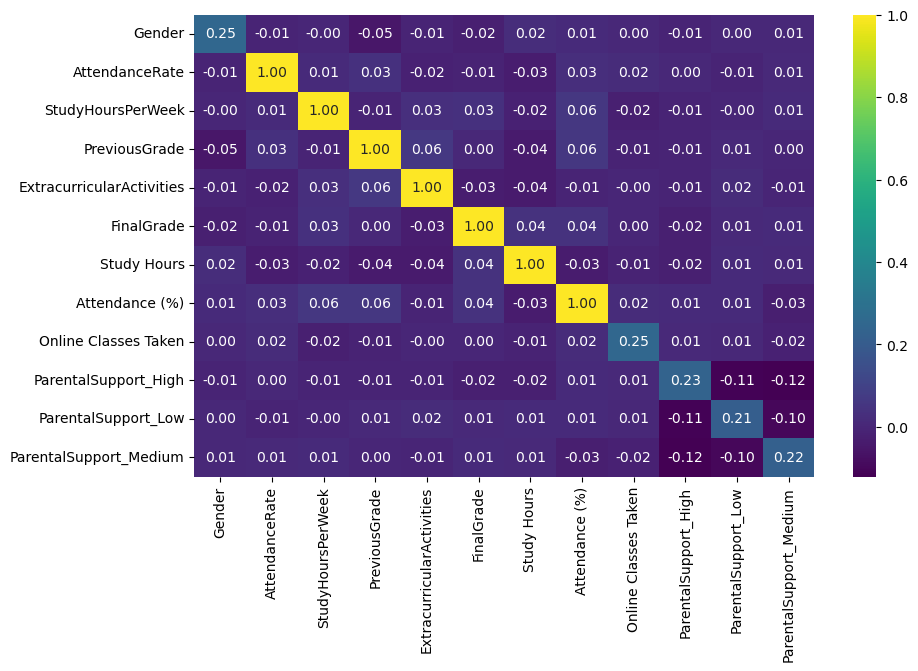

In [27]:
plt.figure(figsize = (10, 6))
sns.heatmap(covv, cmap = 'viridis', annot = True, fmt = '.2f')


In [28]:
display(df.columns)

Index(['Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
       'ExtracurricularActivities', 'FinalGrade', 'Study Hours',
       'Attendance (%)', 'Online Classes Taken', 'ParentalSupport_High',
       'ParentalSupport_Low', 'ParentalSupport_Medium'],
      dtype='object')

<Axes: xlabel='Gender', ylabel='AttendanceRate'>

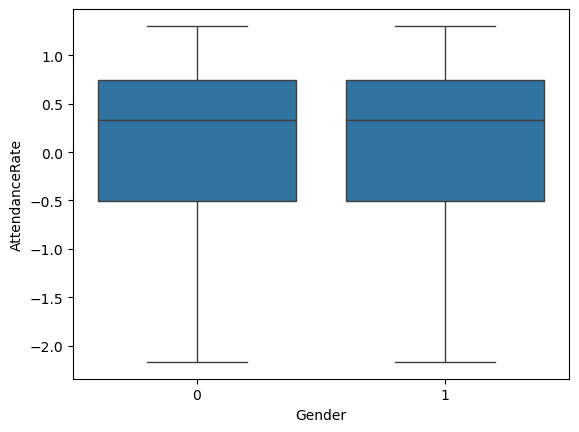

In [29]:
sns.boxplot(df, x = 'Gender', y = 'AttendanceRate')

<Axes: xlabel='Gender', ylabel='StudyHoursPerWeek'>

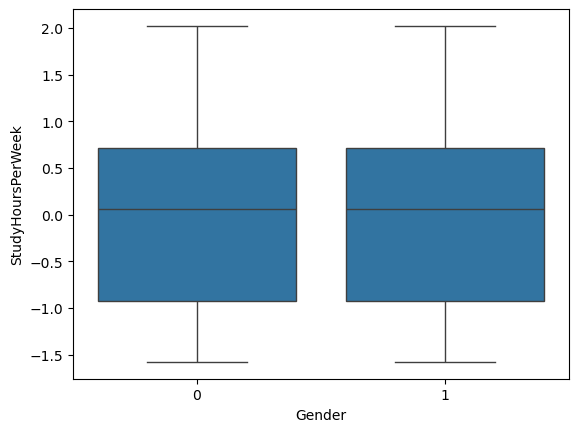

In [30]:
sns.boxplot(df, x = 'Gender', y = 'StudyHoursPerWeek')

<Axes: xlabel='Gender', ylabel='PreviousGrade'>

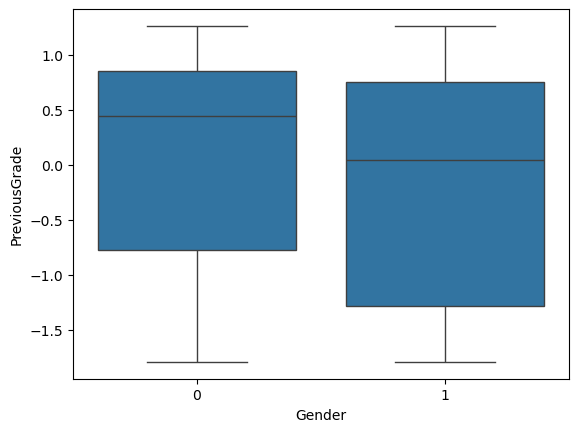

In [31]:
sns.boxplot(df, x = 'Gender', y = 'PreviousGrade')

<Axes: xlabel='Gender', ylabel='FinalGrade'>

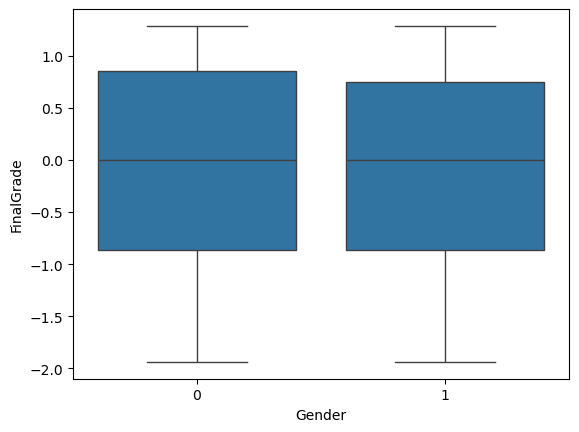

In [32]:
sns.boxplot(df, x = 'Gender', y = 'FinalGrade')

<Axes: xlabel='Gender', ylabel='FinalGrade'>

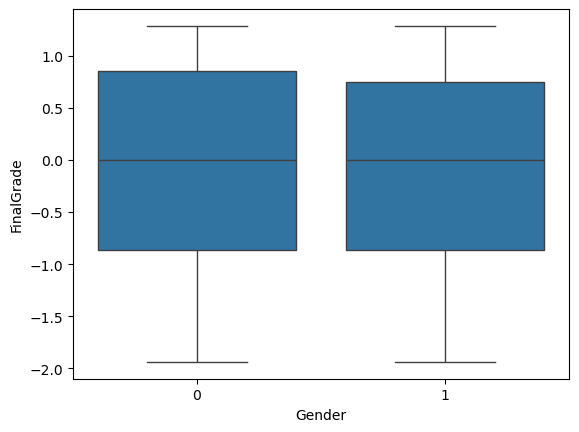

In [38]:
sns.boxplot(x = df.Gender, y = df['FinalGrade'])

<Axes: xlabel='Gender', ylabel='Online Classes Taken'>

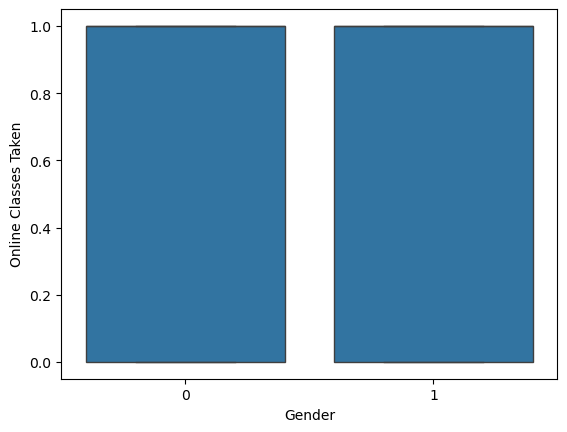

In [45]:
sns.boxplot(x = df.Gender, y = df['Online Classes Taken'])